# Revisão # 

## Regressão linear ##

### 1. A Essência do Modelo ###

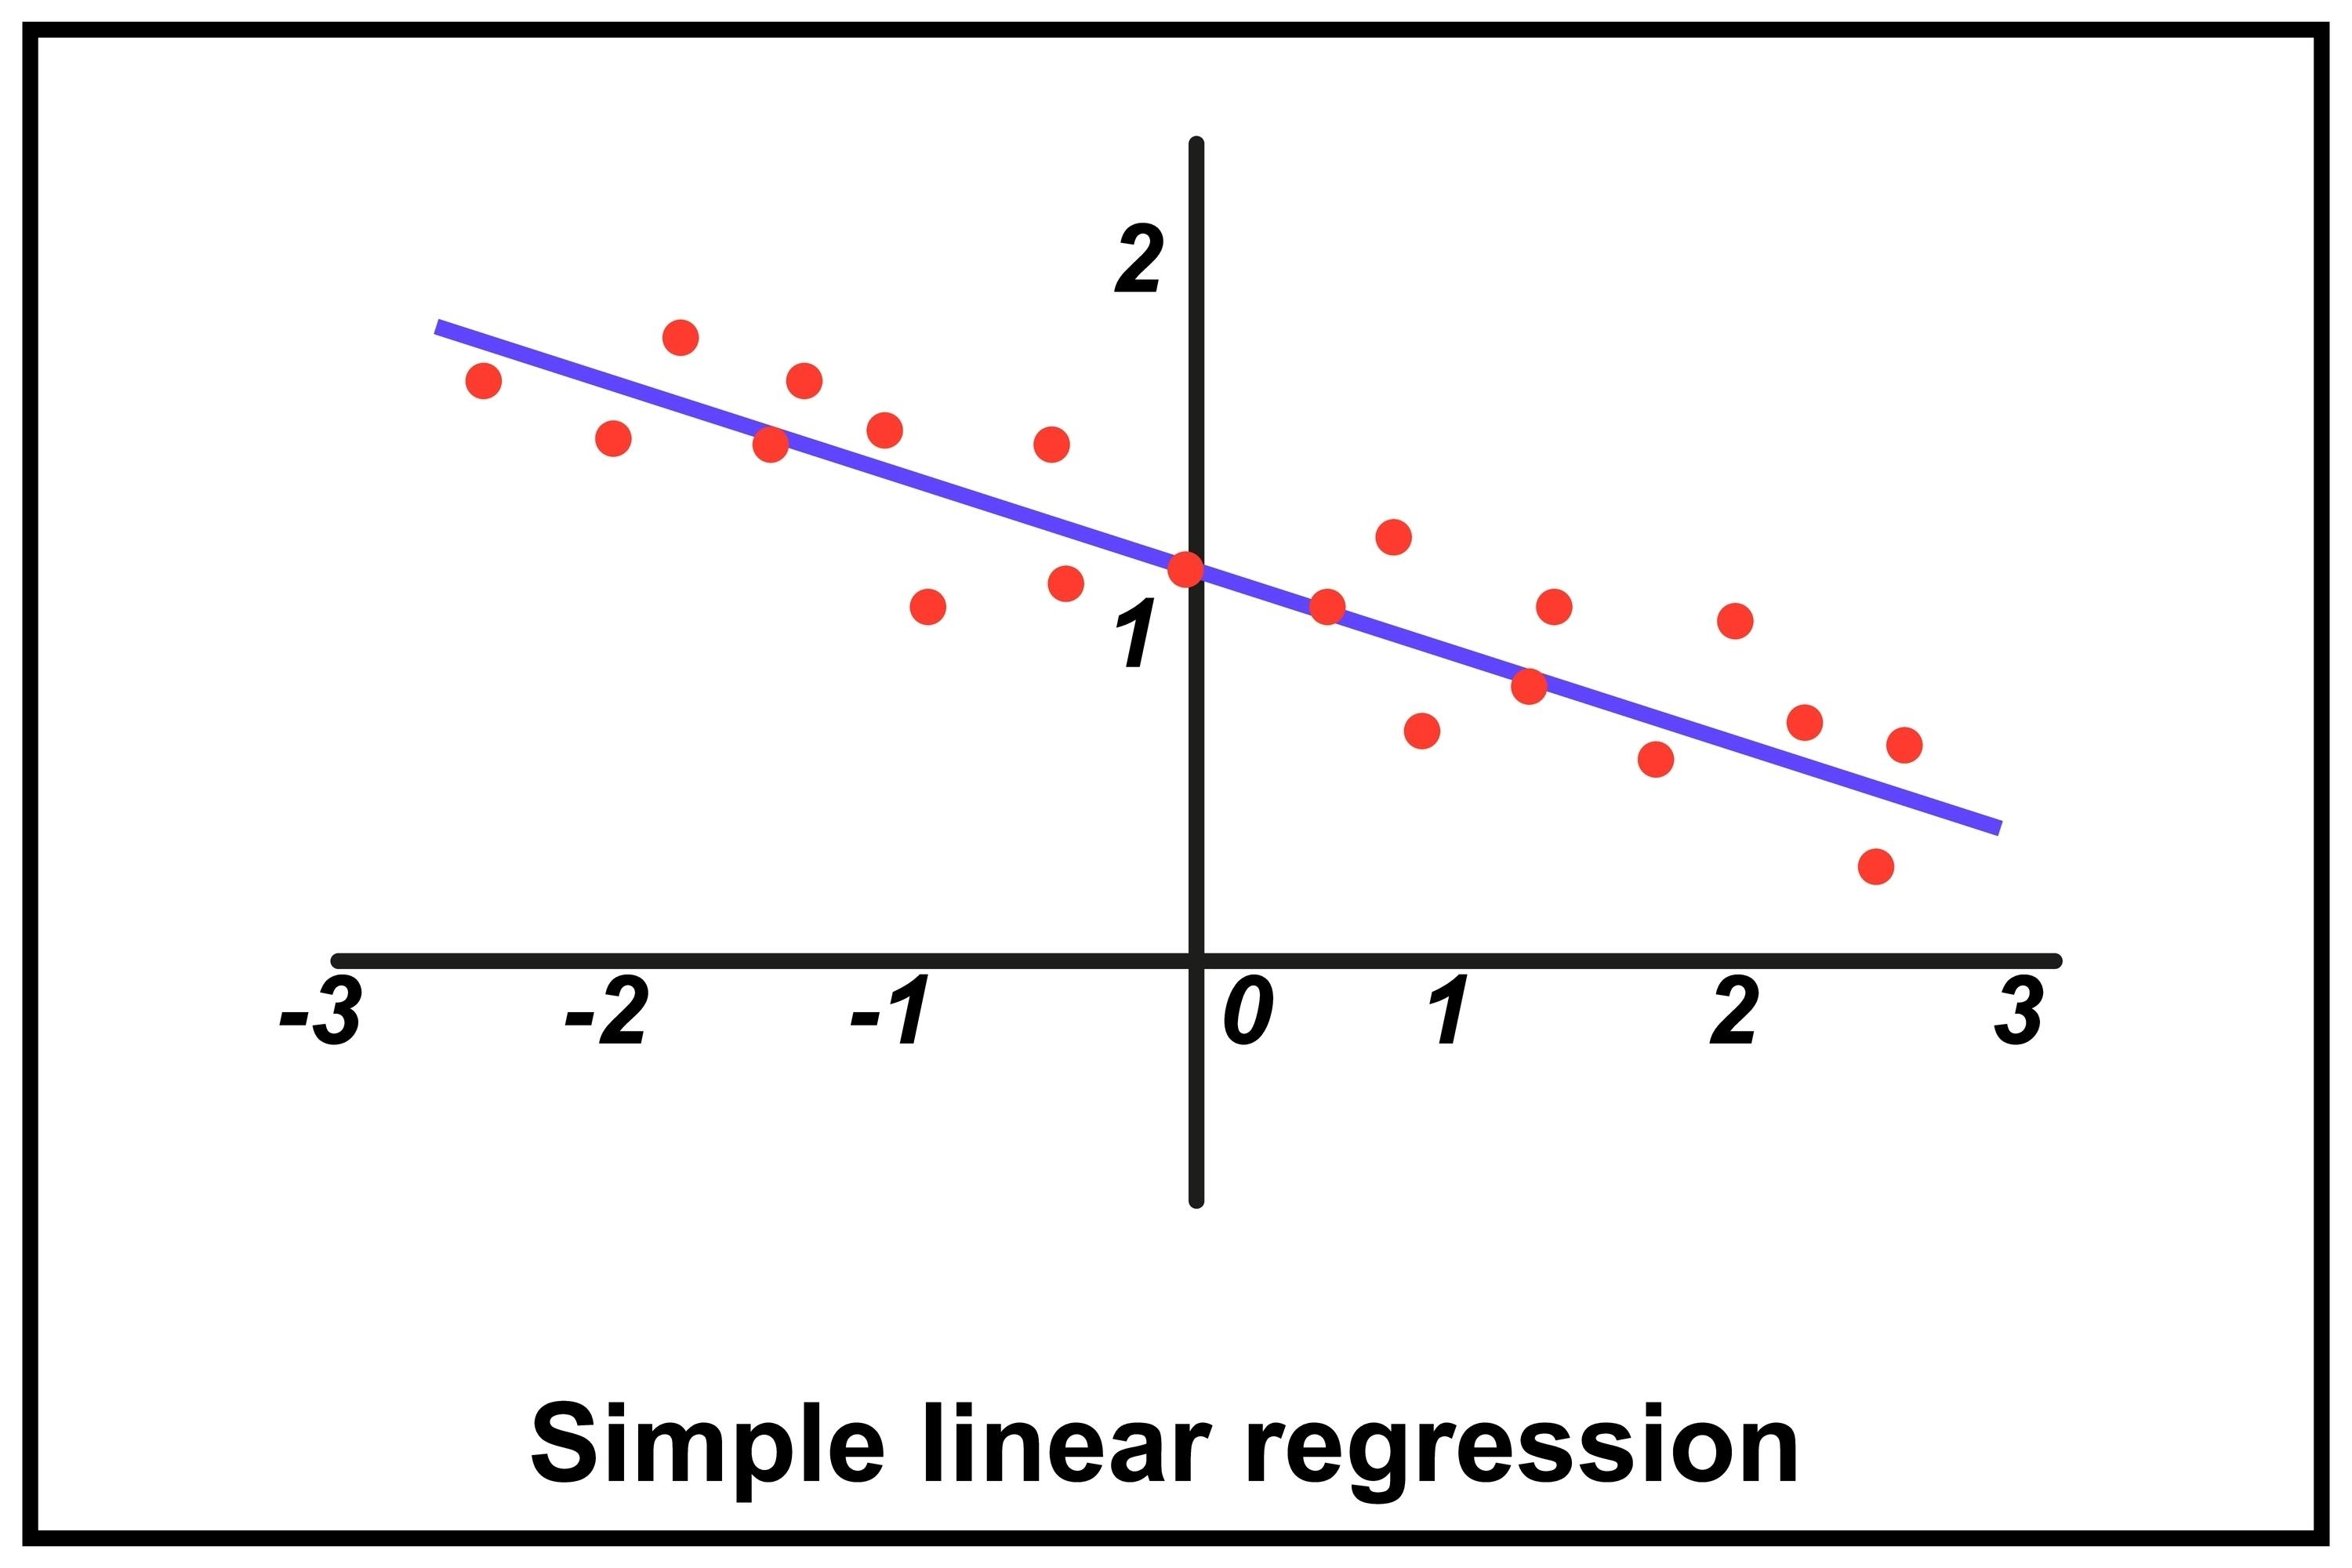

Na sua essência, a Regressão Linear tenta fazer algo muito intuitivo: *traçar a "melhor linha reta" possível através de uma nuvem de pontos de dados.* O objetivo principal (a tarefa) é sempre **prever um valor numérico contínuo.** Por exemplo, prever o tamanho de um rato com base no seu peso, ou prever o preço de uma casa com base na sua área.

**A Matemática por trás:**

Na escola, aprendemos a equação da reta simples: $y = mx + b$.

Em Ciência de Dados, costumamos escrever esta equação vetorialmente, como viu no capítulo 4 do Hands-on:

$$\hat{y} = \theta_0 + \theta_1 x_1 + \theta_2 x_2 + \dots + \theta_n x_n$$

- $\hat{y}$ (y-chapéu): É a nossa previsão (o valor que a reta indica).

- $\theta_0$ (Bias / Interceção): É o ponto onde a reta corta o eixo vertical (Y) quando todas as variáveis $X$ são zero.

- $\theta_1, \theta_2, \dots$ (Pesos / Declives): Indicam a inclinação da reta. Dizem-nos o quanto a nossa previsão $\hat{y}$ aumenta se a variável $x$ aumentar uma unidade.

### 2. O Motor do Algoritmo: Mínimos Quadrados (Least Squares) ###

Como é que o computador sabe qual é a "melhor" reta? Afinal, poderíamos desenhar infinitas retas no gráfico. A resposta é o método dos **Mínimos Quadrados Ordinários** *(Ordinary Least Squares - OLS).*

1. **O Resíduo:** Para qualquer reta desenhada, a distância vertical entre o ponto de dado real e a linha prevista chama-se resíduo (o nosso erro de previsão).

2. **O Quadrado:** Se apenas somássemos os resíduos, os erros positivos (pontos acima da reta) e negativos (pontos abaixo) anular-se-iam. Portanto, elevamos cada resíduo ao quadrado. Isto também ajuda a "castigar" fortemente os erros grandes.

3. **A Minimização:** O algoritmo de Regressão Linear calcula a matemática para encontrar exatamente a combinação de $\theta_0$ e $\theta_1$ que resulta na menor **Soma dos Quadrados dos Resíduos (SSR)** possível. Onde a curva desta soma atinge o ponto mais baixo (a derivada é igual a zero), temos a nossa reta ideal!

### 3. Como avaliamos o modelo? O $R^2$ (R-quadrado) ###

Depois de o algoritmo encontrar a melhor reta, a pergunta que se impõe é: *"Esta reta é sequer útil?"*

Como viu no conceito de $R^2$ do StatQuest, o R-quadrado é uma métrica de correlação altamente interpretável. Ele diz-nos qual é a **percentagem da variação nos nossos dados que é explicada pelo modelo.**

- Se calcularmos um $R^2 = 0.60$ num modelo que prevê o tamanho de ratos pelo seu peso, isso significa que **60% da variação** no tamanho dos ratos é explicada pelo facto de eles terem pesos diferentes. Os restantes 40% devem-se a outros fatores (genética, alimentação, etc.) que não estão no modelo.

- Quanto mais próximo de 1 (ou 100%), mais perfeitamente a nossa reta explica o fenómeno.



### 4. As 5 Premissas Ocultas da Regressão Linear ###

A Regressão Linear Clássica (OLS - Mínimos Quadrados Ordinários) não é apenas uma ferramenta de desenho geométrico; é um modelo probabilístico. Para que os seus resultados (como o p-value e o $R^2$) sejam confiáveis, os dados precisam respeitar cinco regras de ouro. Se estas regras forem violadas, dizemos que o modelo é inválido ou enviesado.

1. **Linearidade:** A relação entre a variável preditora (X) e a variável alvo (Y) tem que ser genuinamente linear. Se a verdadeira relação for uma curva (ex: crescimento exponencial), uma linha reta fará previsões terríveis.

2. **Independência dos Resíduos:** As observações não podem ter relação umas com as outras. Isso é frequentemente violado em séries temporais (onde o preço de hoje depende do preço de ontem). Se houver dependência, o modelo subestima o verdadeiro erro.

3. **Homocedasticidade (Variância Constante):** "Homo" (igual) + "Cedasticidade" (dispersão). Significa que o erro do modelo deve ser consistente ao longo de todos os valores previstos. Se o erro aumenta à medida que os valores crescem (formando um formato de "cone" ou "funil" no gráfico de resíduos), temos Heterocedasticidade, o que torna as previsões para valores altos muito incertas.

4. **Normalidade dos Resíduos:** Os erros (resíduos) que o modelo comete devem seguir uma *Distribuição Normal (a famosa curva em formato de sino),* centrada no zero. Ou seja, o modelo deve cometer pequenos erros com muita frequência e grandes erros muito raramente.

5. **Ausência de Multicolinearidade (Apenas em Regressão Múltipla):** As variáveis de entrada (X1, X2, etc.) não podem ser altamente correlacionadas entre si. Se você usar o "Peso em Kg" e o "Peso em Libras" no mesmo modelo, o algoritmo "enlouquece" ao tentar dividir a importância entre os dois, tornando os coeficientes matematicamente instáveis.

### 5. Métricas de Validação: Como sabemos se o modelo é bom? ###

No mundo da regressão, nós prevemos números contínuos. Logo, a nossa métrica não é "taxa de acerto" (acurácia), mas sim "tamanho do erro".


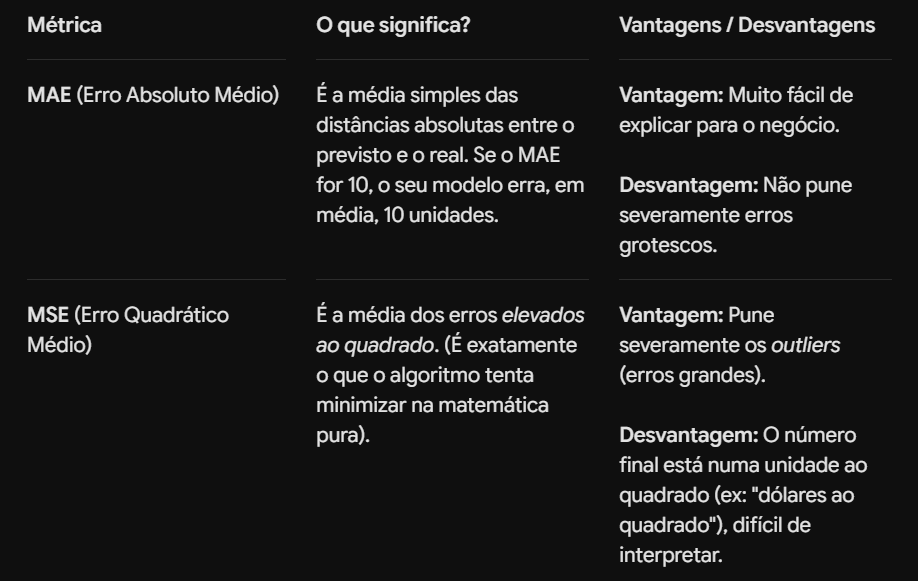

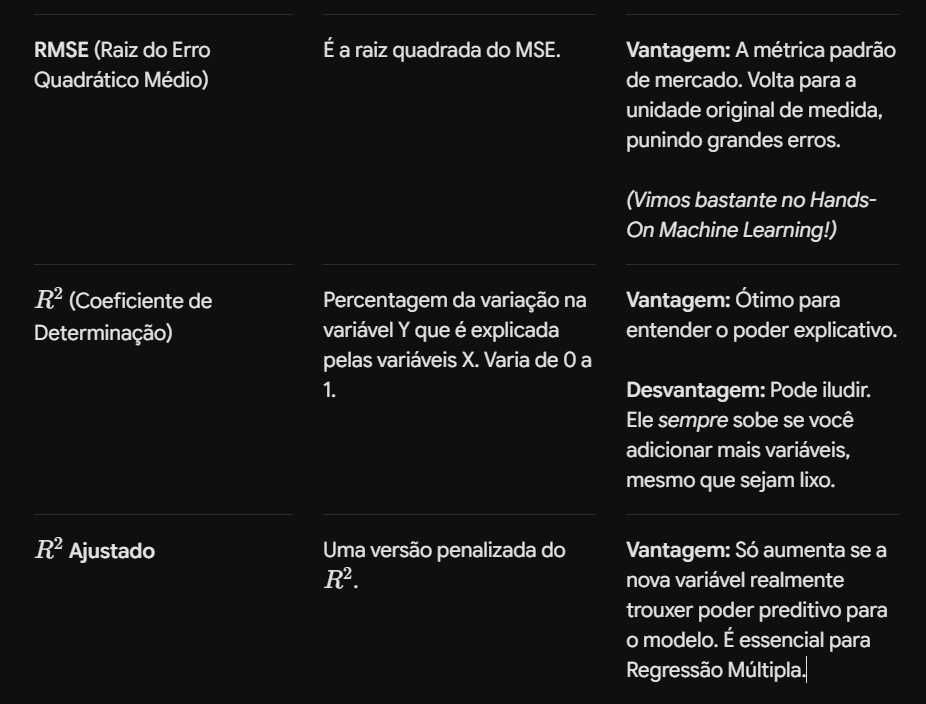

### 6.Hiperparâmetros da Regressão Linear ### 

Aqui entra a grande pegadinha conceitual: **A Regressão Linear Clássica (puro OLS) NÃO possui hiperparâmetros!** O Scikit-Learn vai rodar a matemática exata e achar a resposta única. Não há nada para você "afinar" antes do treino.

Porém, quando o nosso modelo puro sofre de *Overfitting* ou quebra a premissa de Multicolinearidade, nós aplicamos a **Regularização.** É nesse momento que a Regressão Linear ganha "superpoderes" e hiperparâmetros. Temos três sabores clássicos:

1. **Regressão Ridge (Norma L2):**

- **O que faz:** Adiciona uma penalidade matemática que "encolhe" os coeficientes das variáveis para próximo de zero, mas não os zera. Ótima para combater multicolinearidade.

- **Hiperparâmetro Principal:** alpha ($\alpha$). Controla a força da penalidade. $\alpha = 0$ é igual à Regressão Normal. Um $\alpha$ gigante empurra a reta quase para uma linha horizontal (subajuste).

2. **Regressão Lasso (Norma L1):**

- **O que faz:** Pode "encolher" os coeficientes a zero absoluto. Isso significa que o Lasso faz seleção de variáveis automaticamente, ignorando colunas inúteis do seu dataset.

- **Hiperparâmetro Principal:** alpha ($\alpha$). Funciona da mesma forma que no Ridge, mas com punição mais severa que leva à exclusão de colunas.

3. **Regressão Elastic Net:**

- **O que faz:** O melhor dos dois mundos. Combina as penalidades Ridge e Lasso juntas.

- **Hiperparâmetros Principais:** alpha (força total da regularização) e l1_ratio (que decide qual a proporção da mistura. Ex: l1_ratio=0.5 significa 50% Lasso, 50% Ridge).